Notebook 3 - Freestyle

Multi-Resistance Antibiotic Susceptibility
Bacterial isolates, risk factors, and antibiotic resistance profiles across mult

In [4]:
# import Libraries

import pandas as pd
import numpy as np
import statistics as stats
from scipy import stats

In [ ]:
# import do dataset
data = pd.read_csv('data\Bacteria_dataset_Multiresictance.csv')
display(data)

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,Mrs. Chelsea Brown MD,mrs..chelsea.brown.md@example.com,"23574 Palmer Lodge, South Aliciaton, GU 00728",17/M,S7382 Enterobacteria spp.,No,No,No,3.0,...,S,S,S,S,S,S,S,S,2024-12-31,see file
10706,S10996,Mary Kelley,mary.kelley@example.com,"8194 Gonzalez Hill, Loveview, SD 31189",20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,...,S,S,S,S,S,S,S,S,5 Fev 2025,Patient had fever??
10707,S10997,Alexandra Smith,alexandra.smith@example.com,"213 Yates Station, Port Meganstad, PW 17799",33/M,S2983 Escherichia coli,No,No,No,0.0,...,S,S,R,S,R,S,S,S,08/05/2021,Patient had fever??
10708,S10998,April Cox,april.cox@example.com,"985 Julia Freeway Apt. 753, Dianamouth, SD 07610",86/F,S10079 Escherichia coli,No,No,No,2.0,...,s,i,r,r,s,Intermediate,r,s,05/03/2022,see file


In [6]:
# columns names
data.columns

Index(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes',
       'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC',
       'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx',
       'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date',
       'Notes'],
      dtype='object')

In [7]:
# modification of columns names

data.columns = ["ID", "Nome", "E-mail", "Endereço", "Idade/Gênero", "Cepas", "Diabetes",
 "Hipertensão", "Hospitalização_prévia", "Frequência_de_infecção", "Amoxicilina/Ampicilina",
 "Amoxicilina_Clavulanato", "Cefazolina", "Cefoxitina", "Cefotaxima/Ceftriaxona", 
 "Imipeném", "Gentamicina", "Ácido_nalidíxico", "Ácido_nalidíxico", "Ofloxacina", 
 "Ciprofloxacina", "Cloranfenicol", "Co-trimoxazol", "Furanos", "Colistina", 
 "Data_de_Coleta", "Observações"]


In [8]:
# Display the modified DataFrame
display(data)

,ID,Nome,E-mail,Endereço,Idade/Gênero,Cepas,Diabetes,Hipertensão,Hospitalização_prévia,Frequência_de_infecção,...,Ácido_nalidíxico,Ácido_nalidíxico,Ofloxacina,Ciprofloxacina,Cloranfenicol,Co-trimoxazol,Furanos,Colistina,Data_de_Coleta,Observações
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,Mrs. Chelsea Brown MD,mrs..chelsea.brown.md@example.com,"23574 Palmer Lodge, South Aliciaton, GU 00728",17/M,S7382 Enterobacteria spp.,No,No,No,3.0,...,S,S,S,S,S,S,S,S,2024-12-31,see file
10706,S10996,Mary Kelley,mary.kelley@example.com,"8194 Gonzalez Hill, Loveview, SD 31189",20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,...,S,S,S,S,S,S,S,S,5 Fev 2025,Patient had fever??
10707,S10997,Alexandra Smith,alexandra.smith@example.com,"213 Yates Station, Port Meganstad, PW 17799",33/M,S2983 Escherichia coli,No,No,No,0.0,...,S,S,R,S,R,S,S,S,08/05/2021,Patient had fever??
10708,S10998,April Cox,april.cox@example.com,"985 Julia Freeway Apt. 753, Dianamouth, SD 07610",86/F,S10079 Escherichia coli,No,No,No,2.0,...,s,i,r,r,s,Intermediate,r,s,05/03/2022,see file


In [9]:
# Display the first 11 rows of the DataFrame
data.head(11)

,ID,Nome,E-mail,Endereço,Idade/Gênero,Cepas,Diabetes,Hipertensão,Hospitalização_prévia,Frequência_de_infecção,...,Ácido_nalidíxico,Ácido_nalidíxico,Ofloxacina,Ciprofloxacina,Cloranfenicol,Co-trimoxazol,Furanos,Colistina,Data_de_Coleta,Observações
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA
5,S295,Krystal Riley,krystal.riley@example.com,"USNS Neal, FPO AA 98816",57/M,S295 Escherichia coli,True,No,No,3.0,...,R,S,S,S,S,S,S,S,2020-01-05,Patient had fever??
6,S296,Gina Griffin,gina.griffin@example.com,"389 Ferguson Island, West Jefferymouth, MT 89882",68/F,S296 Escherichia coli,No,No,No,3.0,...,S,S,S,S,S,S,S,S,2020-12-31,see file
7,S297,Faith Newman,faith.newman@example.com,"256 Bartlett Fork Suite 334, East Sherri, MI 9...",18/F,S297 Citrobacter spp.,No,No,No,2.0,...,S,S,S,S,S,R,S,S,05/03/2022,تم العلاج
8,S298,Russell Hicks,russell.hicks@example.com,"77940 Richard Brook Apt. 748, South Jessica, G...",77/F,S298 Enterobacteria spp.,No,No,No,0.0,...,S,S,S,S,S,S,S,S,05/01/2025,MALADIE GRAVE
9,S299,Kimberly Rodriguez,kimberly.rodriguez@example.com,"1979 Kayla Squares Suite 125, West Cynthia, MO...",36/F,S299 Proeus mirabilis,No,No,No,3.0,...,S,R,S,S,S,S,S,S,08/05/2021,Patient had fever??


In [10]:
data.columns

Index(['ID', 'Nome', 'E-mail', 'Endereço', 'Idade/Gênero', 'Cepas', 'Diabetes',
       'Hipertensão', 'Hospitalização_prévia', 'Frequência_de_infecção',
       'Amoxicilina/Ampicilina', 'Amoxicilina_Clavulanato', 'Cefazolina',
       'Cefoxitina', 'Cefotaxima/Ceftriaxona', 'Imipeném', 'Gentamicina',
       'Ácido_nalidíxico', 'Ácido_nalidíxico', 'Ofloxacina', 'Ciprofloxacina',
       'Cloranfenicol', 'Co-trimoxazol', 'Furanos', 'Colistina',
       'Data_de_Coleta', 'Observações'],
      dtype='object')

Hypothesis

Check whether there is an association between the type of bacteria (strains) and resistance to the antibiotic Ciprofloxacin (CIP).

H₀ (Null Hypothesis): The type of bacteria (strains) and resistance to Ciprofloxacin (CIP) are independent.

H₁ (Alternative Hypothesis): The type of bacteria and resistance are not independent (that is, there is an association).

Why the Chi-square test:

Because it compares the observed frequencies (how many bacteria of each type are resistant/sensitive)

with the expected frequencies (what would be expected if there were no relationship between the bacterial type and resistance).

In [11]:
# function to standardize the resistance values

def padronizar_resistencia(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    if x in ['r', 'resistente', 'resistance']:
        return 'R'
    elif x in ['s', 'sensivel', 'sensível', 'susceptible', 'sensible']:
        return 'S'
    elif x in ['i', 'intermediate', 'intermédiaire', 'intermédiante']:
        return 'I'
    else:
        return None

In [12]:
# List of antibiotics to be standardized

antibioticos = [
    'Ciprofloxacina',
    'Ofloxacina',
    'Cloranfenicol',
    'Amicacina',
    'Trimetoprima + Sulfametoxazol',
    'Nitrofurantoína',
    'Colistina'
]

In [13]:
# convert the resistance values to standardized format for each antibiotic column

for ab in antibioticos:
    if ab in data.columns:
        data[ab] = data[ab].apply(padronizar_resistencia)

In [14]:
# drop intermediate values
df_cip = data[data['Ciprofloxacina'].isin(['R', 'S'])]

Function to convert everything to standardized uppercase:

“r”, “Resistant” → "R"

“s”, “Sensitive” → "S"

“intermediate”, “I” → "I"

In [15]:
# test chi-square de independência entre Ciprofloxacina e Ofloxacina

from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# drop intermediate values for both antibiotics

data = data.dropna(subset=['Cepas', 'Ciprofloxacina'])

In [17]:
# create contingency table

tabela = pd.crosstab(data['Cepas'], data['Ciprofloxacina'])
print("📊 Tabela de Contingência:")
print(tabela)

📊 Tabela de Contingência:
Ciprofloxacina           I  R  S
Cepas                           
S1000 Proteus mirabilis  0  1  0
S10000 Escherichia coli  0  0  1
S10001 Citrobacter spp.  0  0  1
S10002 Escherichia coli  0  0  1
S10003 Escherichia coli  0  0  1
...                     .. .. ..
S9995 E.cli              0  0  1
S9996 Escherichia coli   0  0  1
S9997 Escherichia coli   0  0  1
S9998 E.coi              0  0  1
S9999 Escherichia coli   0  0  2

[9296 rows x 3 columns]


Why a contingency table?

They are the starting point for studying the relationships between categorical variables.

A contingency table shows the frequency of occurrence of combinations between two (or more) categorical variables.

In [18]:
chi2, p, dof, expected = chi2_contingency(tabela)

print("\n🔍 Chi-Square Test Results:")
print(f"Chi-square statistic χ² = {chi2:.3f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p:.4f}")


🔍 Chi-Square Test Results:
Chi-square statistic χ² = 19894.000
Degrees of freedom = 18590
p-value = 0.0000


In [19]:
if p < 0.05:
    print("Reject H₀ → There is a significant association between the type of bacteria and resistance to CIP.")
else:
    print("Do not reject H₀ → There is no significant association between the type of bacteria and resistance to CIP.")


Reject H₀ → There is a significant association between the type of bacteria and resistance to CIP.


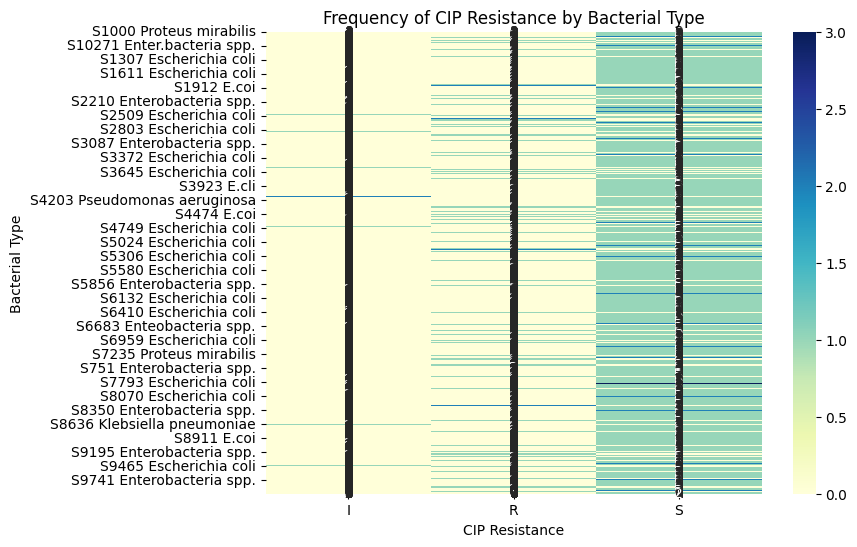

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(tabela, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Frequency of CIP Resistance by Bacterial Type")
plt.xlabel("CIP Resistance")
plt.ylabel("Bacterial Type")
plt.show()



Regarding the graph:

Columns:

“R” (Resistant)

“S” (Sensitive)

“I” (Intermediate)

Darker colors → indicate more observations.

If some bacteria have many more “R” than “S”, this suggests an association.

The p-value was less than 0.05, so there is a significant association between the type of bacteria and resistance to the antibiotic CIP.
